In [1]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

from demos.ControlledPendulum.src.master_pendulum import MasterPendulum
import demos.ControlledPendulum.src.master_pendulum.components.fem.pendulum_config as config

from syssimx import FMUComponent, Connection, System, SystemGraphVisualizer

In [2]:
PLATFORM = sys.platform
demo_dir_path = Path().cwd() / "demos" / "ControlledPendulum"
package_path = Path(demo_dir_path / "src/modelica/ControlledPendulum")
fmu_output_dir = Path(demo_dir_path / f"artifacts/fmus/{PLATFORM}")

fmu_paths = {}
for subdir in fmu_output_dir.iterdir():
    if subdir.is_dir():
        fmu_paths[subdir.name] = {}
        for fmu_file in subdir.glob("*.fmu"):
            fmu_paths[subdir.name][fmu_file.stem] = fmu_file
        for subsubdir in subdir.iterdir():
            fmu_paths[subdir.name][subsubdir.name] = {}
            if subsubdir.is_dir():
                fmu_paths[subdir.name][subsubdir.name] = {}
                for fmu_file in subsubdir.glob("*.fmu"):
                    fmu_paths[subdir.name][subsubdir.name][fmu_file.stem] = fmu_file
    else:
        fmu_paths[subdir.stem] = subdir

In [23]:
from OMPython import ModelicaSystem
reference = ModelicaSystem(fileName=str(package_path / "package.mo"),
                           modelName="ControlledPendulum.Examples.NoContact.Baseline")
reference.buildModel()
reference.simulate()
ref_sol_names = ('time', 'theta', 'omega', 'u_control', 'tau')
ref_sol = {name: reference.getSolutions(name).flatten() for name in ref_sol_names}


Notification: Automatically loaded package Complex 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package ModelicaServices 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package Modelica 4.0.0 due to usage.


LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.
LOG_SUCCESS       | info    | The simulation finished successfully.


In [24]:
setpoint = FMUComponent(name="Setpoint",
                         fmu_path=fmu_paths['Trajectories']["SetPoint"],
                         group="Reference")

pid = FMUComponent(name="PID",
                   fmu_path=fmu_paths['Controllers']["PIDController"],
                   group="Controller")

drive = FMUComponent(name="Drive",
                     fmu_path=fmu_paths['Actuators']["DriveDynamic"],
                     group="Actuator")

pendulum = FMUComponent(name="Pendulum",
                        fmu_path=fmu_paths['Plants']["Pendulum_cvode"],
                        group="Plant")

c1 = Connection(
    src_comp=setpoint.name,
    src_port=setpoint.output_specs["theta_ref"].name,
    dst_comp=pid.name,
    dst_port=pid.input_specs["theta_ref"].name,
)

c2 = Connection(
    src_comp=pendulum.name,
    src_port=pendulum.output_specs["theta"].name,
    dst_comp=pid.name,
    dst_port=pid.input_specs["theta_meas"].name,
)

c3 = Connection(
    src_comp=pid.name,
    src_port=pid.output_specs["u"].name,
    dst_comp=drive.name,
    dst_port=drive.input_specs["u_control"].name,
)

c4 = Connection(
    src_comp=drive.name,
    src_port=drive.output_specs["torque"].name,
    dst_comp=pendulum.name,
    dst_port=pendulum.input_specs["tau"].name,
)

c5 = Connection(
    src_comp=pendulum.name,
    src_port=pendulum.output_specs["omega"].name,
    dst_comp=drive.name,
    dst_port=drive.input_specs["omega"].name,
)

connections = [c1, c2, c3, c4, c5]
components  = [setpoint, pid, drive, pendulum]


system = System(name="Controlled Pendulum System")

for comp in components:
    system.add_component(comp)

for conn in connections:
    system.add_connection(conn)

system.initialize(t0=0.0)


# visualizer = SystemGraphVisualizer(system)
# visualizer.visualize()

t = 0.0
dt = 0.001
t_end = 2.0

system.run(t0=t, tf=t_end, dt=dt)

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF
LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_S

In [25]:
history = system.get_history()

t_sys = history['Setpoint'][0]
theta = history['Pendulum'][1]['theta']
omega = history['Pendulum'][1]['omega']
u_control = history['PID'][1]['u']
tau = history['Drive'][1]['torque']

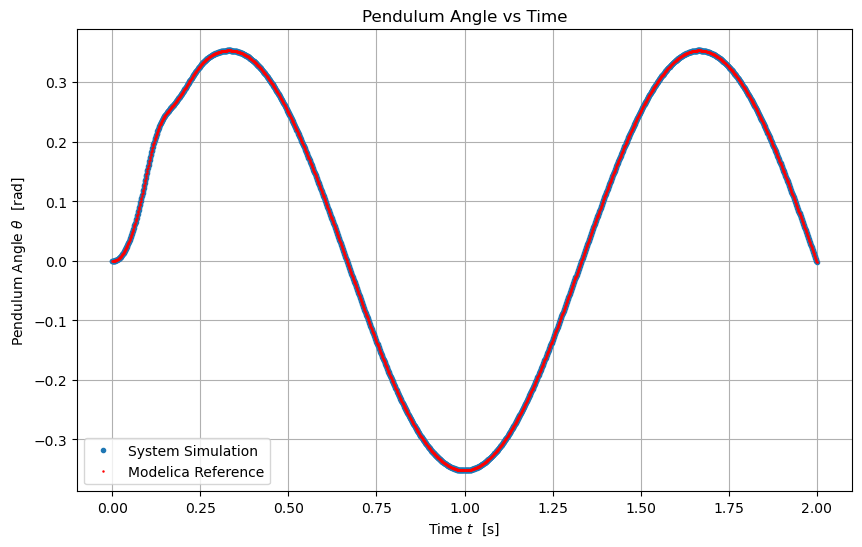

In [52]:
plt.figure(figsize=(10, 6))
plt.plot(t_sys, theta, 'o', label="System Simulation", color="#1f77b4", markersize=3)
plt.plot(ref_sol['time'], ref_sol['theta'], 'ro', label="Modelica Reference", markersize=0.75)
# plt.xlim(0, 0.1)
# plt.ylim(-0.0, 0.18)
plt.xlabel(r"Time $t$  [s]")
plt.ylabel(r"Pendulum Angle $\theta$  [rad]")
plt.title("Pendulum Angle vs Time")
plt.grid()
plt.legend()
plt.show()

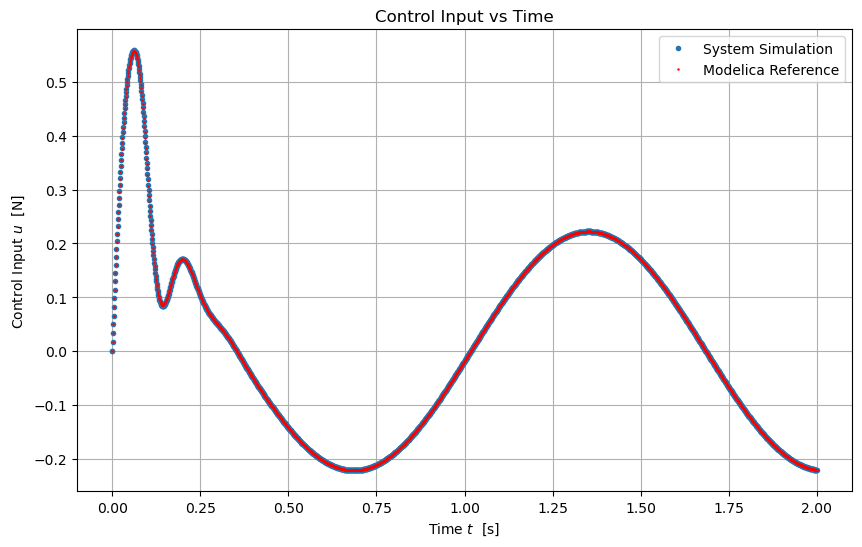

In [54]:
plt.figure(figsize=(10, 6))
plt.plot(t_sys, u_control, 'o', label="System Simulation", color="#1f77b4", markersize=3)
plt.plot(ref_sol['time'], ref_sol['u_control'],  'ro', label="Modelica Reference", markersize=0.75)
#plt.xlim(0, 0.1)
#plt.ylim(-0.0, 0.18)
plt.xlabel(r"Time $t$  [s]")
plt.ylabel(r"Control Input $u$  [N]")
plt.title("Control Input vs Time")
plt.grid()
plt.legend()
plt.show()

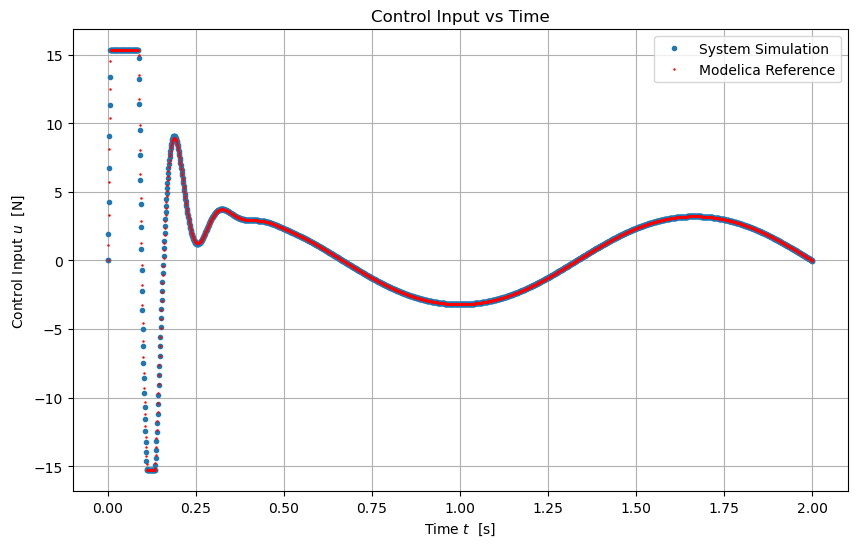

In [55]:
plt.figure(figsize=(10, 6))
plt.plot(t_sys, tau, 'o', label="System Simulation", color="#1f77b4", markersize=3)
plt.plot(ref_sol['time'], ref_sol['tau'], 'ro', label="Modelica Reference", markersize=0.75)
#plt.xlim(0, 0.1)
#plt.ylim(-0.0, 0.18)
plt.xlabel(r"Time $t$  [s]")
plt.ylabel(r"Control Input $u$  [N]")
plt.title("Control Input vs Time")
plt.grid()
plt.legend()
plt.show()